# Weather, Gas, and Price Correlations — HB_HOUSTON

Notebooks 01 and 02 characterized *how* prices are distributed and *when* they spike. This notebook asks a complementary question: **which exogenous drivers actually move with price?** We focus on two families of candidates:

- **Weather** — temperature, apparent temperature, wind (10 m and 100 m), cloud cover, shortwave radiation, direct normal irradiance, relative humidity, and dewpoint. These shape load (heating/cooling demand) and renewable supply (wind, solar).
- **Fuel** — the Henry Hub natural gas spot price, which sets marginal fuel cost for the combined-cycle and peaker units that clear most high-price hours on ERCOT.

All analysis uses `HB_HOUSTON` as the representative hub. Correlations are computed on the raw hourly series (prices uncapped). For the scatter plots we cap the y-axis at `$500/MWh` so the long right tail doesn't squash the body of the distribution — the fits and correlations themselves use the full data.

## 1. Setup and subset

We reuse the same path / styling conventions as notebook 02 so the figures look consistent across the project. The season mapping is meteorological (Dec–Feb = Winter, Jun–Aug = Summer, etc.). The weather variable list is fixed here once so that every downstream plot and the saved correlation matrix iterate over the same set in the same order.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'ercot_merged_dataset.parquet'
OUTPUTS_DIR = PROJECT_ROOT / 'outputs'
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.size': 12,
})

PRICE_CAP = 500.0  # visualization cap only; correlations & fits use uncapped data
RANDOM_STATE = 7

SEASON_MAP = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Fall',  10: 'Fall',  11: 'Fall',
}
SEASON_ORDER = ['Winter', 'Spring', 'Summer', 'Fall']
SEASON_COLORS = {
    'Winter': '#4c78a8',
    'Spring': '#54a24b',
    'Summer': '#e45756',
    'Fall':   '#f58518',
}

WEATHER_VARS = [
    ('temperature_2m',           'Temperature (2 m)'),
    ('apparent_temperature',     'Apparent temperature'),
    ('wind_speed_10m',           'Wind speed (10 m)'),
    ('wind_speed_100m',          'Wind speed (100 m)'),
    ('cloud_cover',              'Cloud cover'),
    ('shortwave_radiation',      'Shortwave radiation'),
    ('direct_normal_irradiance', 'Direct normal irradiance'),
    ('relative_humidity_2m',     'Relative humidity'),
    ('dewpoint_2m',              'Dewpoint'),
]

df = pd.read_parquet(DATA_PATH)
hh = df[df['Location'] == 'HB_HOUSTON'].copy()
hh['season'] = hh['month'].map(SEASON_MAP)

print(f'HB_HOUSTON rows: {len(hh):,}')
print(f'Date range: {hh["datetime"].min()} -> {hh["datetime"].max()}')
print(f'Price range: ${hh["SPP"].min():.2f} to ${hh["SPP"].max():.2f}; mean ${hh["SPP"].mean():.2f}')

HB_HOUSTON rows: 63,791
Date range: 2019-01-01 00:00:00 -> 2026-04-11 23:00:00
Price range: $-0.13 to $8995.11; mean $56.34


## 2. `weather_correlations.png` — correlations by season

The grouped horizontal bar chart shows the correlation between hourly `SPP` and each weather variable under three slices: **All hours**, **Summer (Jun–Aug)**, and **Winter (Dec–Feb)**. Splitting by season matters because the sign of the relationship can flip — e.g. higher temperatures raise prices in summer (AC load) but lower them in winter (less heating). A single pooled correlation averages those two regimes and tends to understate both.

In [ ]:
def corr_by_slice(frame, slice_mask):
    sub = frame.loc[slice_mask]
    return {var: sub[['SPP', var]].corr().iloc[0, 1] for var, _ in WEATHER_VARS}

slices = {
    'All hours': pd.Series(True, index=hh.index),
    'Summer (Jun\u2013Aug)': hh['month'].isin([6, 7, 8]),
    'Winter (Dec\u2013Feb)': hh['month'].isin([12, 1, 2]),
}

corr_table = pd.DataFrame({label: corr_by_slice(hh, mask) for label, mask in slices.items()})
corr_table.index = [label for _, label in WEATHER_VARS]
print(corr_table.round(3))

fig, ax = plt.subplots(figsize=(11, 7))
y = np.arange(len(WEATHER_VARS))
bar_h = 0.26
slice_colors = {
    'All hours': '#4e5b6b',
    'Summer (Jun\u2013Aug)': SEASON_COLORS['Summer'],
    'Winter (Dec\u2013Feb)': SEASON_COLORS['Winter'],
}
for i, label in enumerate(corr_table.columns):
    ax.barh(y + (i - 1) * bar_h, corr_table[label].values, height=bar_h,
            color=slice_colors[label], label=label, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_yticks(y)
ax.set_yticklabels(corr_table.index)
ax.invert_yaxis()
ax.set_xlabel('Correlation with HB_HOUSTON price')
ax.set_title('Weather\u2013price correlations by season (HB_HOUSTON, hourly)')
ax.legend(loc='lower right', framealpha=0.9)
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / 'weather_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

**Reading the bars.** Temperature and apparent temperature are the cleanest split: strongly *positive* in summer (AC-driven load) and *negative* in winter (colder hours = higher prices, driven by heating demand and events like Winter Storm Uri), so the pooled correlation lands near zero because the two regimes roughly cancel. Local wind speeds correlate only weakly and slightly *positively* — counterintuitive at first, but expected here: the Houston weather zone's near-surface wind reflects coastal sea-breeze patterns, not the West/Panhandle wind that actually sets ERCOT's wind fleet output. So local wind is a poor proxy for system-wide wind generation at this hub. Solar proxies (shortwave radiation, DNI) are mildly positive in summer because they co-occur with mid-day AC load; humidity and dewpoint are weakly negative because high-humidity hours on the Gulf tend to be nighttime/off-peak.

## 3. `price_vs_temperature.png` — U-shape of price vs. temperature

A scatter of hourly price against `temperature_2m` should show the classic U-shape: prices rise at both temperature extremes. Summer heat drives AC load; the cold tail captures winter heating demand (and, in Texas, the occasional gas-supply crunch — Winter Storm Uri in February 2021 is visible as a cluster of very high prices at the coldest temperatures). A random 10k-point sample avoids overplotting; the OLS fit quantifies how much of the variance a simple linear model captures (spoiler: not much, because the underlying relationship is quadratic).

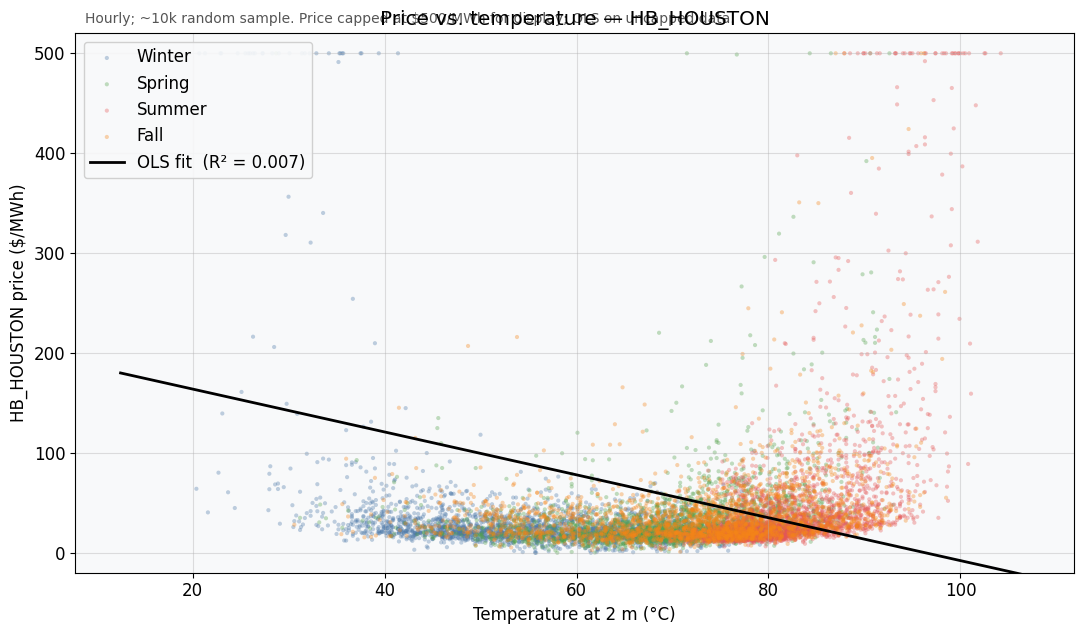

OLS price ~ temperature_2m:  slope=-2.147  intercept=206.824  R²=0.0070


In [3]:
def ols_fit(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    slope, intercept = np.polyfit(x, y, 1)
    y_pred = slope * x + intercept
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else float('nan')
    xs = np.linspace(x.min(), x.max(), 200)
    ys = slope * xs + intercept
    return xs, ys, r2, slope, intercept

sample = hh[['SPP', 'temperature_2m', 'wind_speed_100m', 'season']].dropna()
sample = sample.sample(n=min(10_000, len(sample)), random_state=RANDOM_STATE)

# OLS on the FULL uncapped hourly data so R^2 isn't dominated by sampling noise.
full_temp = hh[['SPP', 'temperature_2m']].dropna()
xs, ys, r2, slope, intercept = ols_fit(full_temp['temperature_2m'], full_temp['SPP'])

fig, ax = plt.subplots(figsize=(11, 6.5))
for season in SEASON_ORDER:
    s = sample[sample['season'] == season]
    ax.scatter(s['temperature_2m'], s['SPP'].clip(upper=PRICE_CAP),
               s=9, alpha=0.35, color=SEASON_COLORS[season], label=season,
               edgecolors='none')
ax.plot(xs, np.clip(ys, None, PRICE_CAP), color='black', linewidth=2,
        label=f'OLS fit  (R\u00b2 = {r2:.3f})')
ax.set_ylim(-20, PRICE_CAP + 20)
ax.set_xlabel('Temperature at 2 m (\u00b0C)')
ax.set_ylabel('HB_HOUSTON price ($/MWh)')
ax.set_title('Price vs. temperature \u2014 HB_HOUSTON')
ax.text(0.01, 1.02, f'Hourly; ~10k random sample. Price capped at ${PRICE_CAP:.0f}/MWh for display; OLS on uncapped data.',
        transform=ax.transAxes, fontsize=10, color='#555', ha='left')
ax.legend(loc='upper left', framealpha=0.9)
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / 'price_vs_temperature.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'OLS price ~ temperature_2m:  slope={slope:.3f}  intercept={intercept:.3f}  R\u00b2={r2:.4f}')

**Reading the scatter.** Summer points (red) concentrate on the right and show the steepest upward drift toward `$500+`. Winter points (blue) cluster on the left; a handful of extreme-cold hours sit at or above the cap — those are the Uri-era rows. The straight OLS line is a poor summary of a clearly non-monotone cloud: its R² is low because a linear fit averages the upward summer arm with the downward/flat winter arm. The takeaway is that temperature matters *a lot*, but any model that uses it linearly will leave explanatory power on the table — something like a spline, GAM, or interaction with season is likely to help.

## 4. `price_vs_wind.png` — price vs. 100 m wind speed

Wind turbines sit roughly at 80–120 m, so `wind_speed_100m` is the standard proxy for wind-generation potential. The theoretical prior is a *negative* slope (more wind → more cheap MWh → lower prices), but we should be careful: the wind feature we have here is measured at the Houston weather zone, while ERCOT's wind fleet is concentrated in the West and Panhandle zones. So what we'll actually see here is whatever local Gulf wind has to say about Houston-hub prices, which is a weaker instrument than it first appears.

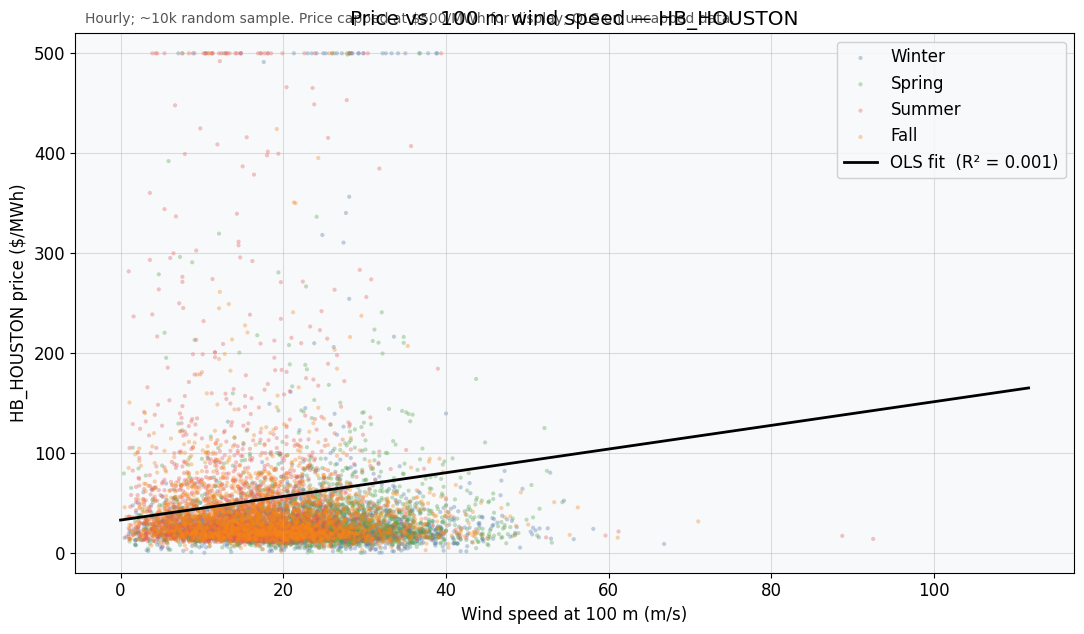

OLS price ~ wind_speed_100m:  slope=1.185  intercept=32.716  R²=0.0010


In [4]:
full_wind = hh[['SPP', 'wind_speed_100m']].dropna()
xs, ys, r2, slope, intercept = ols_fit(full_wind['wind_speed_100m'], full_wind['SPP'])

fig, ax = plt.subplots(figsize=(11, 6.5))
for season in SEASON_ORDER:
    s = sample[sample['season'] == season]
    ax.scatter(s['wind_speed_100m'], s['SPP'].clip(upper=PRICE_CAP),
               s=9, alpha=0.35, color=SEASON_COLORS[season], label=season,
               edgecolors='none')
ax.plot(xs, np.clip(ys, None, PRICE_CAP), color='black', linewidth=2,
        label=f'OLS fit  (R\u00b2 = {r2:.3f})')
ax.set_ylim(-20, PRICE_CAP + 20)
ax.set_xlabel('Wind speed at 100 m (m/s)')
ax.set_ylabel('HB_HOUSTON price ($/MWh)')
ax.set_title('Price vs. 100 m wind speed \u2014 HB_HOUSTON')
ax.text(0.01, 1.02, f'Hourly; ~10k random sample. Price capped at ${PRICE_CAP:.0f}/MWh for display; OLS on uncapped data.',
        transform=ax.transAxes, fontsize=10, color='#555', ha='left')
ax.legend(loc='upper right', framealpha=0.9)
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / 'price_vs_wind.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'OLS price ~ wind_speed_100m:  slope={slope:.3f}  intercept={intercept:.3f}  R\u00b2={r2:.4f}')

**Reading the scatter.** The linear slope is essentially flat (R² ≈ 0.001) — Houston's local 100 m wind speed does not move the hub price on average. That's consistent with the structural point: ERCOT's installed wind capacity sits in the West zone and Panhandle, not on the Gulf, so the weather measured at Houston is the wrong instrument for gauging wind generation. What the cloud *does* show is an asymmetry: the `$500`-cap outliers cluster at low-to-moderate wind speeds and are scarce at the highest winds. Wind enters the modeling story through interaction with the correct weather zones, not as a standalone local feature at HB_HOUSTON.

## 5. `price_vs_gas.png` — daily gas vs. daily electricity price

Gas is the marginal fuel for most ERCOT hours, so the theory predicts a clear positive relationship: roughly `P_electric ≈ heat_rate × P_gas + margin`. We aggregate both series to the daily level (daily mean of hourly prices, and the daily Henry Hub value) so the comparison is apples-to-apples — the gas price in the dataset is a daily spot value broadcast to every hour.

In [ ]:
daily = (hh.groupby('date')
           .agg(price=('SPP', 'mean'), gas=('gas_price_henry_hub', 'first'))
           .dropna())

xs, ys, r2, slope, intercept = ols_fit(daily['gas'], daily['price'])
corr_daily = daily['gas'].corr(daily['price'])

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.scatter(daily['gas'], daily['price'].clip(upper=PRICE_CAP),
           s=14, alpha=0.45, color='#4c78a8', edgecolors='none',
           label='Daily average')
ax.plot(xs, np.clip(ys, None, PRICE_CAP), color='black', linewidth=2,
        label=f'OLS fit  (R\u00b2 = {r2:.3f})')
ax.set_ylim(-20, PRICE_CAP + 20)
ax.set_xlabel('Henry Hub natural gas price ($/MMBtu)')
ax.set_ylabel('HB_HOUSTON daily mean price ($/MWh)')
ax.set_title('Daily electricity price vs. daily gas price \u2014 HB_HOUSTON')
ax.text(0.01, 1.02, f'Daily aggregation. Price capped at ${PRICE_CAP:.0f}/MWh for display; OLS on uncapped data.',
        transform=ax.transAxes, fontsize=10, color='#555', ha='left')
ax.legend(loc='upper left', framealpha=0.9)
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / 'price_vs_gas.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'OLS daily price ~ gas:  slope={slope:.3f}  intercept={intercept:.3f}  R\u00b2={r2:.4f}')
print(f'Daily correlation (price, gas): {corr_daily:.3f}')

**Reading the scatter.** There is a clear positive drift — higher gas, higher average clearing price — but the points fan out substantially at every gas level. A day with gas at `$3/MMBtu` can end at `$30` or above `$200` depending on weather and reserve margins. The slope is consistent with a reasonable implied heat rate, and this is the strongest *single-feature* linear signal we see in the notebook. Gas is the most useful linear control; weather effects layer on top.

## 6. Correlation matrix — weather + gas vs. price

Finally, we print the full correlation matrix of price with every weather variable and with gas price, then save it to `outputs/correlation_matrix.csv` for downstream reference. Gas is included at its hourly (stepped daily) value so the matrix is fully rectangular over hourly rows.

In [6]:
matrix_cols = ['SPP'] + [v for v, _ in WEATHER_VARS] + ['gas_price_henry_hub']
corr_matrix = hh[matrix_cols].corr()
pd.set_option('display.float_format', lambda v: f'{v: .3f}')
print(corr_matrix)
pd.reset_option('display.float_format')

out_path = OUTPUTS_DIR / 'correlation_matrix.csv'
corr_matrix.to_csv(out_path)
print(f'\nSaved to {out_path.relative_to(PROJECT_ROOT)}')

                            SPP  temperature_2m  apparent_temperature  \
SPP                       1.000          -0.084                -0.085   
temperature_2m           -0.084           1.000                 0.984   
apparent_temperature     -0.085           0.984                 1.000   
wind_speed_10m            0.056          -0.025                -0.140   
wind_speed_100m           0.031          -0.174                -0.264   
cloud_cover              -0.003           0.018                 0.034   
shortwave_radiation       0.034           0.425                 0.346   
direct_normal_irradiance  0.032           0.318                 0.234   
relative_humidity_2m     -0.064          -0.098                 0.038   
dewpoint_2m              -0.112           0.851                 0.909   
gas_price_henry_hub       0.213          -0.089                -0.087   

                          wind_speed_10m  wind_speed_100m  cloud_cover  \
SPP                                0.056         

**Takeaways for modeling.** No single exogenous feature has a strong linear correlation with hourly price — magnitudes sit roughly in the 0.03–0.23 range. That's expected: prices are a nonlinear, threshold-y function of the *joint* state of load, wind, and reserve margin. The directional signals:

- **Gas** is the strongest linear anchor: daily correlation ≈ 0.23 and hourly ≈ 0.21, consistent with gas being the marginal fuel.
- **Temperature** flips sign across seasons (+0.33 summer, −0.23 winter), so pooled correlation hides the real structure — interaction terms or season-specific models should pay off here.
- **Local wind (100 m)** is near-zero at HB_HOUSTON because ERCOT's wind fleet is in West/Panhandle zones, not the Gulf coast. A system-level wind proxy (aggregated across the correct weather zones) is the right feature to engineer before modeling.
- **Solar radiation / DNI** correlate with price mostly through their co-movement with mid-day summer load, not through direct supply effects.
- **Dewpoint** is the most collinear feature with temperature (0.85) and apparent temperature (0.91); keeping both in a linear model risks inflated variance with no added signal.

These correlations set the floor. The Session 7 models (KNN, random forest, splines) should do noticeably better than linear regression on this feature set alone — especially once temperature is allowed to enter non-linearly and wind is re-engineered at the system level.